In [77]:
import rosbag

bagFile = '/home/mark50/dataset/flybag/2024-06-01-exp/2024-09-11-11-34-09.bag'
bagData = rosbag.Bag(bagFile, "r")

bagInfo = bagData.get_type_and_topic_info()
print(bagInfo)

TypesAndTopicsTuple(msg_types={'sensor_msgs/Image': '060021388200f6f0f447d0fcd9c64743', 'sensor_msgs/Imu': '6a62c6daae103f4ff57a132d6f95cec2', 'sensor_msgs/NavSatFix': '2d3a8cd499b9b4a0249fb98fd05cfa48'}, topics={'/course_info': TopicTuple(msg_type='sensor_msgs/Imu', message_count=9425, connections=1, frequency=20.18374830370634), '/gnw_imu/data': TopicTuple(msg_type='sensor_msgs/Imu', message_count=94415, connections=1, frequency=204.18684127254582), '/mavros/global_position/compass_hdg': TopicTuple(msg_type='sensor_msgs/Imu', message_count=4721, connections=1, frequency=10.063181836721473), '/mavros/global_position/raw/fix': TopicTuple(msg_type='sensor_msgs/NavSatFix', message_count=2360, connections=1, frequency=4.988936876799794), '/usb_camera/color/image_raw': TopicTuple(msg_type='sensor_msgs/Image', message_count=472, connections=1, frequency=1.0003596645293498), '/usb_camera/gray/image_raw/10Hz': TopicTuple(msg_type='sensor_msgs/Image', message_count=4717, connections=1, frequen

In [78]:
import sys
print(sys.path)

['', '/opt/ros/noetic/lib/python3/dist-packages', '/usr/lib/python38.zip', '/usr/lib/python3.8', '/usr/lib/python3.8/lib-dynload', '/home/mark50/.local/lib/python3.8/site-packages', '/usr/local/lib/python3.8/dist-packages', '/usr/lib/python3/dist-packages', '/tmp/genpy_oe4qp17m', '/tmp/genpy_3yj8c4rr']


In [79]:
GnssMsgs =  bagData.read_messages("/mavros/global_position/raw/fix")
ImageMsgs = bagData.read_messages("/usb_camera/color/image_raw")

In [80]:
import piexif 

def add_gps_to_jpeg(jpeg_path, lat, lon, altitude):
    exif_dict = {
        piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
        piexif.GPSIFD.GPSLatitudeRef: 'N' if lat >= 0 else 'S',
        piexif.GPSIFD.GPSLongitudeRef: 'E' if lon >= 0 else 'W',
        piexif.GPSIFD.GPSLatitude: _convert_to_dms(lat),
        piexif.GPSIFD.GPSLongitude: _convert_to_dms(lon),
        piexif.GPSIFD.GPSAltitudeRef: 0 if altitude >= 0 else 1,  # 0: above sea level, 1: below sea level
        piexif.GPSIFD.GPSAltitude: _convert_to_rational(altitude),
    }
    exif_bytes = piexif.dump({"GPS": exif_dict})
    
    # Insert the GPS information into the JPEG file
    piexif.insert(exif_bytes, jpeg_path)

def _convert_to_dms(deg):
    deg_abs = abs(deg)
    d = int(deg_abs)
    m = int((deg_abs - d) * 60)
    s = round(((deg_abs - d) * 60 - m) * 60, 3)
    return ((d, 1), (m, 1), (int(s * 1000), 1000))

def _convert_to_rational(altitude):
    altitude = altitude.tolist()
    return (int(round(altitude, 2) * 100), 100)

In [81]:
from pyproj import Transformer

# 参数1：坐标系WKID 广州市 WGS_1984_UTM_Zone_49N 对应 32649
# 参数2：WGS84地理坐标系统 对应 4326
GnssTF = Transformer.from_crs("epsg:32649", "epsg:4326")

In [82]:
import numpy as np

GnssTimeStamp_list, GnssPosData_list = [], []
GnssUTMPosData_list = []
 
for GnssTopic, GnssMsg, GnssTimeStamp in GnssMsgs:
    GnssTimeStamp_list.append(GnssTimeStamp.to_sec())
    GnssPosData_list.append([GnssMsg.latitude, GnssMsg.longitude, GnssMsg.altitude])
    
    UTM_x, UTM_y = GnssTF.transform(GnssMsg.latitude, GnssMsg.longitude)
    GnssUTMPosData_list.append([UTM_x, UTM_y, GnssMsg.altitude])

GnssTimeStamp_array = np.array(GnssTimeStamp_list)
GnssPosData_array = np.array(GnssPosData_list)
GnssUTMPosData_array = np.array(GnssUTMPosData_list)

print(GnssTimeStamp_array.shape, GnssPosData_array.shape, GnssUTMPosData_array.shape)

(2360,) (2360, 3) (2360, 3)


In [83]:
print(GnssPosData_array[:50])

[[ 39.4054433  116.2260743   10.27728017]
 [ 39.4054434  116.2260745   10.28928067]
 [ 39.4054436  116.2260748   10.32828152]
 [ 39.4054438  116.2260751   10.36128236]
 [ 39.4054439  116.2260753   10.37328286]
 [ 39.405444   116.2260755   10.38328336]
 [ 39.405444   116.2260755   10.40728336]
 [ 39.405444   116.2260756   10.4142835 ]
 [ 39.405444   116.2260757   10.43028365]
 [ 39.405444   116.2260757   10.45228365]
 [ 39.4054438  116.2260758   10.44228338]
 [ 39.4054437  116.2260758   10.43728317]
 [ 39.4054436  116.2260757   10.46228282]
 [ 39.4054435  116.2260756   10.48228246]
 [ 39.4054434  116.2260756   10.50228226]
 [ 39.4054434  116.2260754   10.61428197]
 [ 39.4054432  116.2260754   10.81128155]
 [ 39.405443   116.2260755   11.04028128]
 [ 39.4054428  116.2260751   11.32428029]
 [ 39.4054427  116.2260747   11.5962795 ]
 [ 39.4054427  116.2260741   11.93427863]
 [ 39.4054428  116.2260736   12.21927812]
 [ 39.4054431  116.2260733   12.58027831]
 [ 39.4054431  116.2260731   12.94

In [84]:
from scipy.interpolate import interp1d

funcInterp = [interp1d(GnssTimeStamp_array, GnssPosData_array[:, i], kind='cubic', fill_value='extrapolate') for i in range(3)]

In [85]:
import cv2
from cv_bridge import CvBridge
import os
import csv
import numpy as np

# 初始化CvBridge
bridge = CvBridge()

output_folder = "/home/mark50/dataset/flybag/2024-06-01-exp/2024-09-11-11-34-09"
images_folder = os.path.join(output_folder, "images")  # 定义 images 子文件夹

# 如果 images 文件夹不存在则创建
if not os.path.exists(images_folder):
    os.makedirs(images_folder)

# 定义索引和数据列表
idx = 1
ImagePosData_list, ImageTimeStamp_list, ImageUTMPosData_list = [], [], []

# 定义CSV文件路径
csv_file_path = os.path.join(output_folder, "image_gps_map.csv")

# 打开CSV文件准备写入
with open(csv_file_path, mode='w', newline='') as csv_file:
    # 定义CSV文件的列名
    # fieldnames = ['image_name', 'timestamp', 'x', 'y', 'z', 'utm_x', 'utm_y', 'utm_z']
    fieldnames = ['image_name', 'timestamp', 'x', 'y', 'z']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()  # 写入表头

    # 遍历图像消息，保存图像和GPS数据
    for ImageTopic, ImageMsg, ImageTimeStamp in ImageMsgs:

        # 获取图像的GPS位置信息
        ImagePosData = [funcInterp[i](ImageTimeStamp.to_sec()) for i in range(3)]
        ImageTimeStamp_list.append(ImageTimeStamp.to_sec())
        ImagePosData_list.append(ImagePosData)

        # 保存图像文件到 images 文件夹
        image_filename = f"cameraImage_{idx}.jpg"
        image_filepath = os.path.join(images_folder, image_filename)  # 改为保存到 images 文件夹
        cv2.imwrite(image_filepath, bridge.imgmsg_to_cv2(ImageMsg, desired_encoding='bgr8'))

        # 添加GPS信息到图像（假设已有函数add_gps_to_jpeg）
        add_gps_to_jpeg(image_filepath, ImagePosData[0], ImagePosData[1], ImagePosData[2])

        # 获取UTM坐标
        UTM_x, UTM_y = GnssTF.transform(ImagePosData[0], ImagePosData[1])
        ImageUTMPosData_list.append([UTM_x, UTM_y, ImagePosData[2]])

        # 将图像名、时间戳、GPS坐标和UTM坐标写入CSV
        writer.writerow({
            'image_name': image_filename,
            'timestamp': ImageTimeStamp.to_sec(),
            'x': ImagePosData[0],
            'y': ImagePosData[1],
            'z': ImagePosData[2],
            # 'utm_x': UTM_x,
            # 'utm_y': UTM_y,
            # 'utm_z': ImagePosData[2]  # 假设z坐标在UTM中不变
        })

        # 更新索引
        idx += 1

# 转换为numpy数组，便于后续操作
ImagePosData_array = np.array(ImagePosData_list)
ImageTimeStamp_array = np.array(ImageTimeStamp_list)
ImageUTMPosData_array = np.array(ImageUTMPosData_list)

# 打印数组形状确认
print(ImageTimeStamp_array.shape, ImagePosData_array.shape, ImageUTMPosData_array.shape)


(472,) (472, 3) (472, 3)


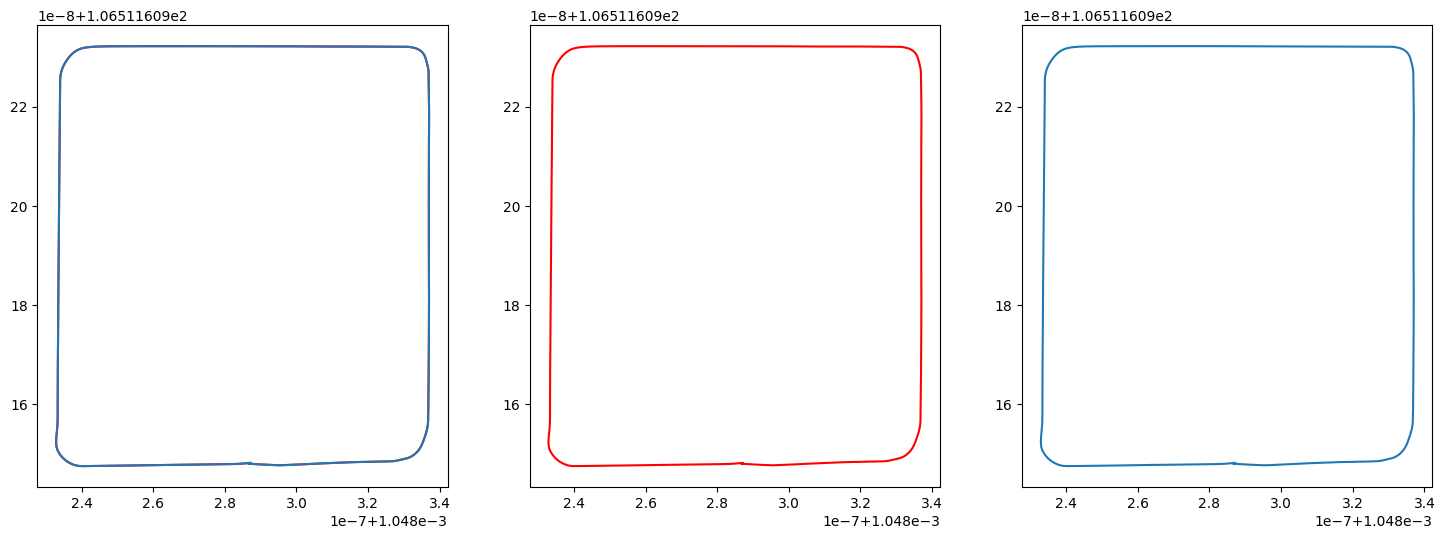

In [87]:
import matplotlib.pyplot as plt

MaxTimeStampIdx = idx - 2
MaxTimeStamp = ImageTimeStamp_array[MaxTimeStampIdx]


fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].plot(GnssUTMPosData_array[:, 0][GnssTimeStamp_array < MaxTimeStamp], GnssUTMPosData_array[:, 1][GnssTimeStamp_array < MaxTimeStamp], 'r')
axs[0].plot(ImageUTMPosData_array[:, 0][ImageTimeStamp_array < MaxTimeStamp], ImageUTMPosData_array[:, 1][ImageTimeStamp_array < MaxTimeStamp])

axs[1].plot(GnssUTMPosData_array[:, 0][GnssTimeStamp_array < MaxTimeStamp], GnssUTMPosData_array[:, 1][GnssTimeStamp_array < MaxTimeStamp], 'r')

axs[2].plot(ImageUTMPosData_array[:, 0][ImageTimeStamp_array < MaxTimeStamp], ImageUTMPosData_array[:, 1][ImageTimeStamp_array < MaxTimeStamp])

In [1]:
import pymap3d as pm
import csv

# Set the ENU Origin (First valid GPS point or mean position)
# Using the first image's GPS position as the local origin for ENU
lat0, lon0, h0 = ImagePosData_array[0][0], ImagePosData_array[0][1], ImagePosData_array[0][2]
print(f"ENU Origin set to: Lat={lat0}, Lon={lon0}, Alt={h0}")

# Convert WGS84 (Lat, Lon, Alt) to ENU (East, North, Up)
enu_data = []
for i in range(len(ImagePosData_array)):
    lat, lon, h = ImagePosData_array[i]
    e, n, u = pm.geodetic2enu(lat, lon, h, lat0, lon0, h0)
    enu_data.append([e, n, u])

enu_data_array = np.array(enu_data)

# Save to CSV
enu_csv_path = os.path.join(output_folder, "image_enu_map.csv")
with open(enu_csv_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    # Header: image_name, east, north, up, timestamp
    writer.writerow(["image_name", "east", "north", "up", "timestamp"])
    
    for i in range(len(enu_data)):
        # Reconstruct image filename using index (assuming idx started at 1 and incremented)
        # Note: In the previous loop, idx ended at len+1. 
        # But here we just need to match the array order.
        # Image i corresponds to cameraImage_{i+1}.jpg
        img_name = f"cameraImage_{i+1}.jpg"
        ts = ImageTimeStamp_array[i]
        e, n, u = enu_data[i]
        
        writer.writerow([img_name, e, n, u, ts])

print(f"ENU coordinates saved to {enu_csv_path}")
print(f"First 5 ENU points:\n{enu_data_array[:5]}")


ModuleNotFoundError: No module named 'pymap3d'